In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/combined_dataset1.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted")

Dataset extracted


In [ ]:
import os
os.listdir("/content/dataset")

['combined_dataset1']

In [ ]:
import os, shutil, random

source_dir = "/content/dataset/combined_dataset1"
target_dir = "/content/dataset_split"

train_ratio = 0.7
val_ratio = 0.15

for cls in os.listdir(source_dir):
    cls_path = os.path.join(source_dir, cls)
    images = os.listdir(cls_path)

    random.shuffle(images)

    train_end = int(len(images)*train_ratio)
    val_end = int(len(images)*(train_ratio+val_ratio))

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    for split in ["train","val","test"]:
        os.makedirs(os.path.join(target_dir, split, cls), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(cls_path,img),
                    os.path.join(target_dir,"train",cls,img))

    for img in val_imgs:
        shutil.copy(os.path.join(cls_path,img),
                    os.path.join(target_dir,"val",cls,img))

    for img in test_imgs:
        shutil.copy(os.path.join(cls_path,img),
                    os.path.join(target_dir,"test",cls,img))

In [ ]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/dataset_split/train",
    image_size=(128,128),
    batch_size=32
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/dataset_split/val",
    image_size=(128,128),
    batch_size=32
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/dataset_split/test",
    image_size=(128,128),
    batch_size=32
)

Found 27293 files belonging to 4 classes.
Found 5850 files belonging to 4 classes.
Found 5849 files belonging to 4 classes.


In [ ]:
class_names = train_ds.class_names
print(class_names)

['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x,y: (normalization_layer(x),y))
val_ds = val_ds.map(lambda x,y: (normalization_layer(x),y))
test_ds = test_ds.map(lambda x,y: (normalization_layer(x),y))

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([

# Block 1
layers.Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(128,128,3)),
layers.BatchNormalization(),
layers.Conv2D(32,(3,3),activation='relu',padding='same'),
layers.BatchNormalization(),
layers.MaxPooling2D((2,2)),

# Block 2
layers.Conv2D(64,(3,3),activation='relu',padding='same'),
layers.BatchNormalization(),
layers.Conv2D(64,(3,3),activation='relu',padding='same'),
layers.BatchNormalization(),
layers.MaxPooling2D((2,2)),

# Block 3
layers.Conv2D(128,(3,3),activation='relu',padding='same'),
layers.BatchNormalization(),
layers.Conv2D(128,(3,3),activation='relu',padding='same'),
layers.BatchNormalization(),
layers.MaxPooling2D((2,2)),

# Block 4
layers.Conv2D(256,(3,3),activation='relu',padding='same'),
layers.BatchNormalization(),
layers.Conv2D(256,(3,3),activation='relu',padding='same'),
layers.BatchNormalization(),
layers.MaxPooling2D((2,2)),

# Block 5
layers.Conv2D(512,(3,3),activation='relu',padding='same'),
layers.BatchNormalization(),
layers.Conv2D(512,(3,3),activation='relu',padding='same'),
layers.BatchNormalization(),
layers.MaxPooling2D((2,2)),


layers.Flatten(),

layers.Dense(512,activation='relu'),
layers.BatchNormalization(),
layers.Dropout(0.5),

layers.Dense(128,activation='relu'),
layers.BatchNormalization(),
layers.Dropout(0.5),

layers.Dense(4,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,16

 Total params: 8,983,716 (34.27 MB)

 Trainable params: 8,978,468 (34.25 MB)

 Non-trainable params: 5,248 (20.50 KB)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30
)

Epoch 1/30
853/853 ━━━━━━━━━━━━━━━━━━━━ 115s 106ms/step - accuracy: 0.4928 - loss: 1.4260 - val_accuracy: 0.6214 - val_loss: 0.9695
Epoch 2/30
853/853 ━━━━━━━━━━━━━━━━━━━━ 65s 76ms/step - accuracy: 0.6706 - loss: 0.8437 - val_accuracy: 0.8068 - val_loss: 0.4762
Epoch 3/30
853/853 ━━━━━━━━━━━━━━━━━━━━ 64s 75ms/step - accuracy: 0.8027 - loss: 0.5042 - val_accuracy: 0.7911 - val_loss: 0.5604
Epoch 4/30
853/853 ━━━━━━━━━━━━━━━━━━━━ 64s 75ms/step - accuracy: 0.8876 - loss: 0.2948 - val_accuracy: 0.8822 - val_loss: 0.3105
Epoch 5/30
853/853 ━━━━━━━━━━━━━━━━━━━━ 64s 75ms/step - accuracy: 0.9356 - loss: 0.1773 - val_accuracy: 0.8605 - val_loss: 0.4158
Epoch 6/30
853/853 ━━━━━━━━━━━━━━━━━━━━ 65s 76ms/step - accuracy: 0.9526 - loss: 0.1357 - val_accuracy: 0.8986 - val_loss: 0.2750
Epoch 7/30
853/853 ━━━━━━━━━━━━━━━━━━━━ 64s 75ms/step - accuracy: 0.9617 - loss: 0.1089 - val_accuracy: 0.9113 - val_loss: 0.2334
Epoch 8/30
853/853 ━━━━━━━━━━━━━━━━━━━━ 64s 76ms/step - accuracy: 0.9698 - loss: 0.0868 

In [ ]:
labels = ["Mild Demented", "Moderate Demented", "Non Demented", "Very Mild Demented"]

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("AI Predicted Stage", fontsize=12)
plt.ylabel("Actual Stage", fontsize=12)

plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.title("Dementia Stage Confusion Matrix", fontsize=14)
plt.tight_layout()

plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━

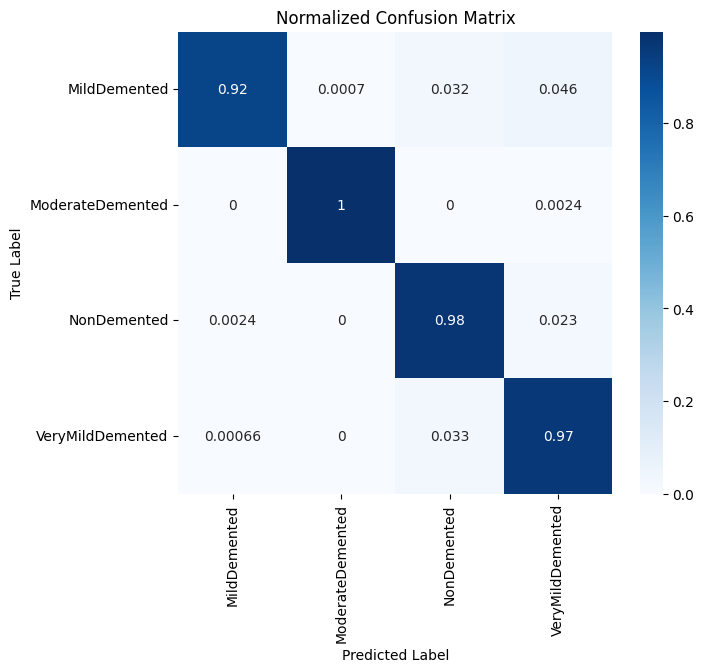

In [ ]:
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_norm,
    annot=True,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.show()

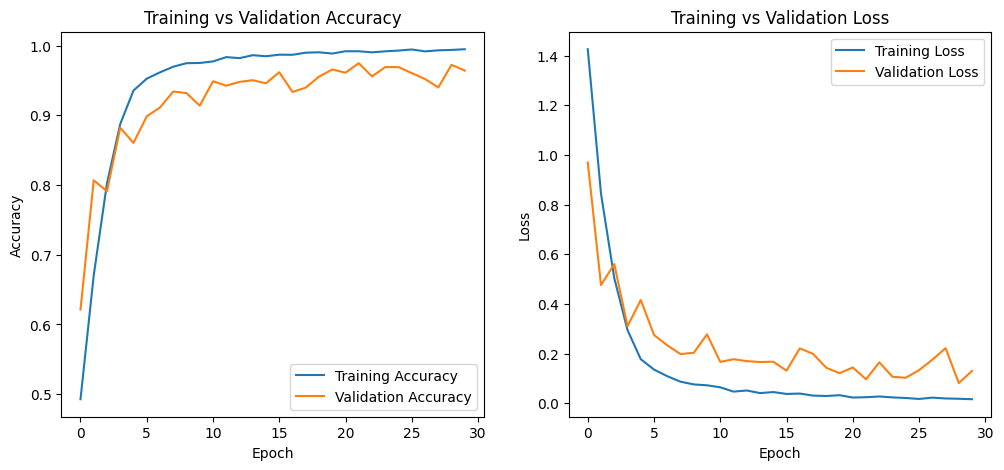

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy curve
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss curve
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━

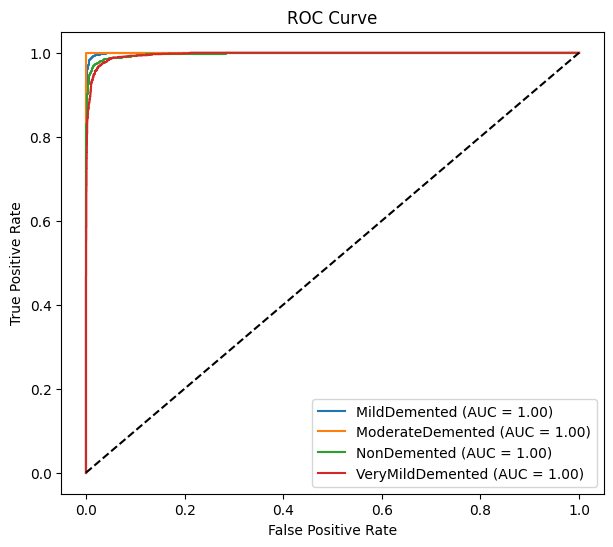

In [ ]:
import numpy as np

y_true = []
y_pred = []
y_prob = []

for images, labels in val_ds:
    preds = model.predict(images)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_prob.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

import matplotlib.pyplot as plt

n_classes = len(class_names)

y_true_bin = label_binarize(y_true, classes=range(n_classes))

plt.figure(figsize=(7,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
model.save("/content/drive/MyDrive/alzheimers_cnn_model3.h5")
model.save("/content/drive/MyDrive/alzheimers_cnn_model3.keras")
import pickle

with open("/content/drive/MyDrive/training_history.pkl", "wb") as f:
    pickle.dump(history.history, f)

In [ ]:
import os
print(os.listdir("/content/drive/MyDrive"))

['NAME : ABHISHEK KUMAR.gdoc', 'Untitled document (2).gdoc', 'SDF WEEK5.gdoc', 'week6 sdf.gdoc', '23103266_Abhishek_W8.gdoc', 'W10_ABHISHEK_23103266.gdoc', 'W13_ABHISHEK_23103266.gdoc', 'W12_ABHISHEK_23103266.gdoc', '10TH_MARKSHEET.pdf', 'Untitled document (1).gdoc', '23103266 Abhishek Meena.gdoc', '23103266 Abhishek Meena.pdf', 'Colab Notebooks', 'Untitled document.gdoc', 'casia2', '<Abhishek> <Meena>.gdoc', 'Copy of <Abhishek> <Meena>.gdoc', 'Abhishek Meena 23103266.gdoc', 'Abhishek Meena 23103266 .pdf', 'Abhishek-Meena.Pdf', '12th marksheet .jpeg', 'SA_PHOTO  .jpeg', 'Issue 1.jpg', 'archive.zip', 'balanced_dataset.zip', 'balanced_dataset', 'alzheimer_cnn_model.h5', 'alzheimer_cnn_model.keras', 'combined_dataset1.zip', 'alzheimer_cnn_model2.h5', 'alzheimer_cnn_model2.keras', 'alzheimers_cnn_model3.h5', 'alzheimers_cnn_model3.keras', 'training_history.pkl']
